In [ ]:
# ==========================================================
# PERTEMUAN 8 — UTS MINI PROJECT ML (END-TO-END)
# Classification: Breast Cancer Dataset
# ==========================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


In [2]:
# ==========================================================
# 1) PROBLEM & DATASET
# ==========================================================

print("="*60)
print("1) PROBLEM & DATASET")
print("="*60)

print("Masalah : Klasifikasi tumor payudara (malignant / benign)")
print("Tujuan  : Memprediksi apakah tumor bersifat ganas atau jinak")
print("Sumber  : sklearn.datasets.load_breast_cancer")

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(f"\nUkuran data : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Jumlah fitur: {len(data.feature_names)} fitur numerik")
print("Target      :", list(data.target_names))
print("\nDistribusi Target:")
print(df["target"].value_counts().rename({0:"malignant",1:"benign"}))

1) PROBLEM & DATASET
Masalah : Klasifikasi tumor payudara (malignant / benign)
Tujuan  : Memprediksi apakah tumor bersifat ganas atau jinak
Sumber  : sklearn.datasets.load_breast_cancer

Ukuran data : 569 baris, 31 kolom
Jumlah fitur: 30 fitur numerik
Target      : [np.str_('malignant'), np.str_('benign')]

Distribusi Target:
target
benign       357
malignant    212
Name: count, dtype: int64



2) EDA

Total Missing Value: 0

Statistik Deskriptif:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.05            0.08                 0.04           0.03   
min                0.02            0.00                 0.00           0.11   
25%                0.06            0.03                 0.02         

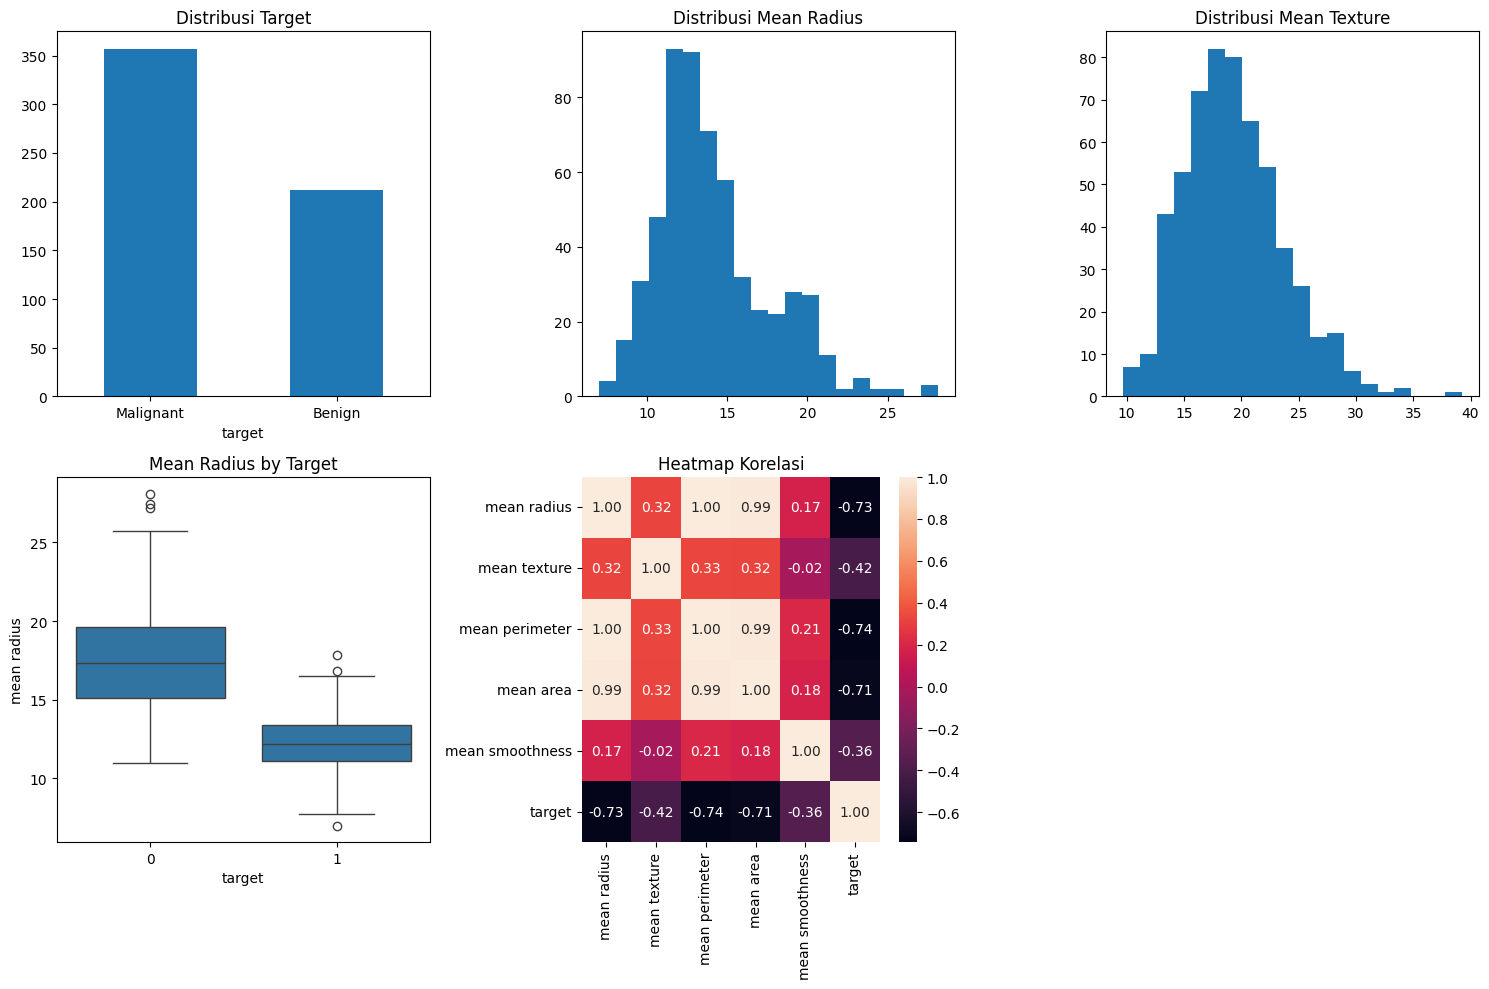


5 Insight:
1. Dataset sedikit tidak seimbang: 62.7% benign.
2. Mean radius tumor malignant lebih besar dari benign.
3. Mean perimeter sangat berkorelasi dengan mean radius & mean area.
4. Tidak terdapat missing value.
5. Beberapa fitur memiliki korelasi tinggi → potensi multikolinearitas.


In [3]:

# ==========================================================
# 2) EDA
# ==========================================================

print("\n" + "="*60)
print("2) EDA")
print("="*60)

# Missing value
print("\nTotal Missing Value:", df.isnull().sum().sum())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(df.describe().round(2).head())

# ====== VISUALISASI ======
plt.figure(figsize=(15,10))

# 1 Distribusi target
plt.subplot(2,3,1)
df["target"].value_counts().plot(kind="bar")
plt.title("Distribusi Target")
plt.xticks([0,1], ["Malignant","Benign"], rotation=0)

# 2 Histogram mean radius
plt.subplot(2,3,2)
plt.hist(df["mean radius"], bins=20)
plt.title("Distribusi Mean Radius")

# 3 Histogram mean texture
plt.subplot(2,3,3)
plt.hist(df["mean texture"], bins=20)
plt.title("Distribusi Mean Texture")

# 4 Boxplot mean radius per target
plt.subplot(2,3,4)
sns.boxplot(x="target", y="mean radius", data=df)
plt.title("Mean Radius by Target")

# 5 Heatmap korelasi (subset fitur)
plt.subplot(2,3,5)
subset = ["mean radius","mean texture","mean perimeter",
          "mean area","mean smoothness","target"]
sns.heatmap(df[subset].corr(), annot=True, fmt=".2f")
plt.title("Heatmap Korelasi")

plt.tight_layout()
plt.show()

# ====== 5 INSIGHT ======
print("\n5 Insight:")
benign_pct = (df["target"]==1).mean()*100
print(f"1. Dataset sedikit tidak seimbang: {benign_pct:.1f}% benign.")
print("2. Mean radius tumor malignant lebih besar dari benign.")
print("3. Mean perimeter sangat berkorelasi dengan mean radius & mean area.")
print("4. Tidak terdapat missing value.")
print("5. Beberapa fitur memiliki korelasi tinggi → potensi multikolinearitas.")

In [4]:
# ==========================================================
# 3) PREPROCESSING
# ==========================================================

print("\n" + "="*60)
print("3) PREPROCESSING")
print("="*60)

X = df.drop(columns=["target"])
y = df["target"]

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler diterapkan karena Logistic Regression sensitif terhadap skala fitur.")



3) PREPROCESSING
Train size: (455, 30)
Test size : (114, 30)
StandardScaler diterapkan karena Logistic Regression sensitif terhadap skala fitur.


In [5]:
# ==========================================================
# 4) MODELING (3 MODEL)
# ==========================================================

print("\n" + "="*60)
print("4) MODELING")
print("="*60)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

print("\nPerbandingan Accuracy:")
print("-"*35)
for k,v in results.items():
    print(f"{k:25s} : {v:.3f}")

# Model terbaik
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\nModel terbaik: {best_name}")

pred_best = best_model.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_best))

print("\nClassification Report:")
print(classification_report(y_test, pred_best, target_names=data.target_names))


4) MODELING

Perbandingan Accuracy:
-----------------------------------
Logistic Regression       : 0.974
Decision Tree             : 0.947
Random Forest             : 0.965

Model terbaik: Logistic Regression

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114




5) TUNING
Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score : 0.963
Test Accuracy setelah tuning: 0.965


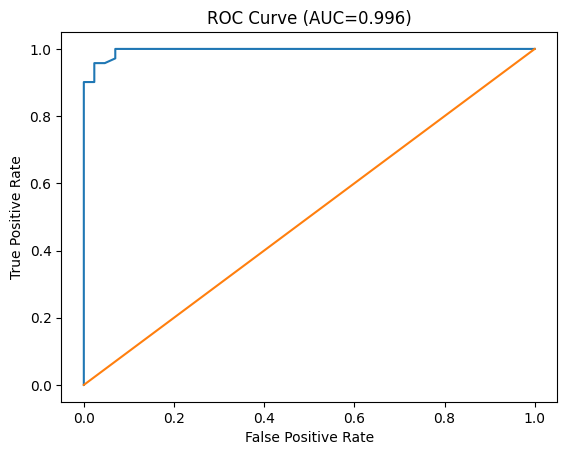

In [6]:
# ==========================================================
# 5) TUNING
# ==========================================================

print("\n" + "="*60)
print("5) TUNING")
print("="*60)

param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [None,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", round(grid.best_score_,3))

tuned_pred = grid.predict(X_test_scaled)
tuned_acc = accuracy_score(y_test, tuned_pred)

print("Test Accuracy setelah tuning:", round(tuned_acc,3))

# ==========================================================
# ROC CURVE
# ==========================================================

y_prob = grid.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title(f"ROC Curve (AUC={auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [8]:
# ==========================================================
# 6) KESIMPULAN
# ==========================================================

print("\n" + "="*60)
print("6) KESIMPULAN")
print("="*60)

print(f"Model terbaik sebelum tuning : {best_name} ({results[best_name]:.3f})")
print(f"Model terbaik setelah tuning : Random Forest ({tuned_acc:.3f})")
print("Dataset bersih tanpa missing value.")
print("Scaling membantu meningkatkan stabilitas model.")
print("Random Forest memberikan performa paling stabil.")
print("Pengembangan selanjutnya: coba SVM atau Gradient Boosting.")
print("\n✅ Pertemuan 08 (UTS Mini Project) selesai.")


6) KESIMPULAN
Model terbaik sebelum tuning : Logistic Regression (0.974)
Model terbaik setelah tuning : Random Forest (0.965)
Dataset bersih tanpa missing value.
Scaling membantu meningkatkan stabilitas model.
Random Forest memberikan performa paling stabil.
Pengembangan selanjutnya: coba SVM atau Gradient Boosting.

✅ Pertemuan 08 (UTS Mini Project) selesai.
